In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Law School dataset from CSV file
df_law = pd.read_csv(
    r'C:\Users\niyat\Desktop\pr\ML-Bias-Fairness\data\law_school\law_dataset.csv'
)

print("Dataset loaded successfully")
print("Shape:", df_law.shape)
print("Columns:", df_law.columns.tolist())
df_law.head()

Dataset loaded successfully
Shape: (18692, 12)
Columns: ['decile1b', 'decile3', 'lsat', 'ugpa', 'zfygpa', 'zgpa', 'fulltime', 'fam_inc', 'male', 'racetxt', 'tier', 'pass_bar']


,decile1b,decile3,lsat,ugpa,zfygpa,zgpa,fulltime,fam_inc,male,racetxt,tier,pass_bar
0,9.0,7.0,46.0,2.9,1.02,0.30,1.0,4.0,1.0,1,3,1
1,6.0,4.0,32.0,3.3,0.24,-0.45,1.0,3.0,0.0,1,3,1
2,7.0,5.0,41.0,3.9,0.54,-0.20,1.0,4.0,0.0,1,4,1
3,7.0,8.0,44.0,3.7,0.54,0.84,1.0,3.0,1.0,1,4,1
4,7.0,7.0,48.0,2.9,0.40,0.52,1.0,5.0,0.0,1,4,1


In [2]:
# ── CELL 2: Basic Info ────────────────────────────
print("=== MISSING VALUES ===")
print(df_law.isnull().sum())

print("\n=== TARGET VARIABLE (pass_bar) ===")
print(df_law['pass_bar'].value_counts())
print(f"\nOverall pass rate: {df_law['pass_bar'].mean()*100:.1f}%")

print("\n=== GENDER DISTRIBUTION ===")
print(df_law['male'].map({1:'Male', 0:'Female'}).value_counts())

print("\n=== RACE DISTRIBUTION ===")
print(df_law['racetxt'].value_counts())

=== MISSING VALUES ===
decile1b    0
decile3     0
lsat        0
ugpa        0
zfygpa      0
zgpa        0
fulltime    0
fam_inc     0
male        0
racetxt     0
tier        0
pass_bar    0
dtype: int64

=== TARGET VARIABLE (pass_bar) ===
pass_bar
1    16856
0     1836
Name: count, dtype: int64

Overall pass rate: 90.2%

=== GENDER DISTRIBUTION ===
male
Male      10550
Female     8142
Name: count, dtype: int64

=== RACE DISTRIBUTION ===
racetxt
1    17491
0     1201
Name: count, dtype: int64


=== BAR EXAM PASS RATE BY GENDER (%) ===
gender
Female    88.98
Male      91.10
Name: pass_bar, dtype: float64


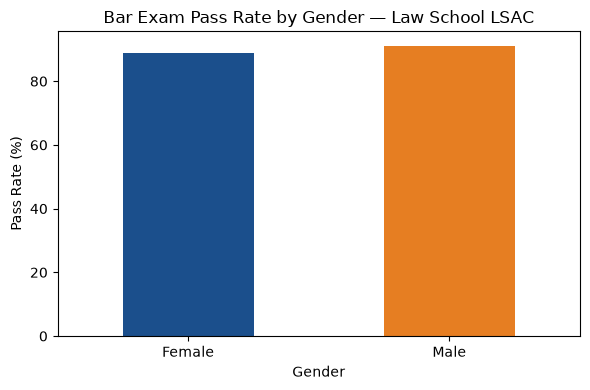

In [3]:
# ── CELL 3: Bias Signal — Pass Rate by Gender ─────
df_law['gender'] = df_law['male'].map({1:'Male', 0:'Female'})

gender_pass = df_law.groupby('gender')['pass_bar'].mean().mul(100).round(2)
print("=== BAR EXAM PASS RATE BY GENDER (%) ===")
print(gender_pass)

plt.figure(figsize=(6,4))
gender_pass.plot(kind='bar', color=['#1B4F8C','#E67E22'])
plt.title('Bar Exam Pass Rate by Gender — Law School LSAC')
plt.ylabel('Pass Rate (%)')
plt.xlabel('Gender')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(r'C:\Users\niyat\Desktop\pr\ML-Bias-Fairness\results\lawschool_pass_by_gender.png', dpi=150)
plt.show()

=== BAR EXAM PASS RATE BY RACE (%) ===
racetxt
0    61.78
1    92.13
Name: pass_bar, dtype: float64


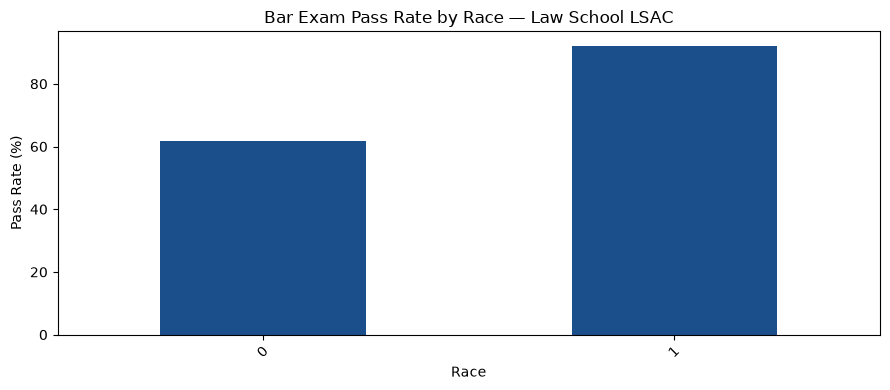

In [4]:
# ── CELL 4: Bias Signal — Pass Rate by Race ───────
race_pass = df_law.groupby('racetxt')['pass_bar'].mean().mul(100).round(2).sort_values()
print("=== BAR EXAM PASS RATE BY RACE (%) ===")
print(race_pass)

plt.figure(figsize=(9,4))
race_pass.plot(kind='bar', color='#1B4F8C')
plt.title('Bar Exam Pass Rate by Race — Law School LSAC')
plt.ylabel('Pass Rate (%)')
plt.xlabel('Race')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(r'C:\Users\niyat\Desktop\pr\ML-Bias-Fairness\results\lawschool_pass_by_race.png', dpi=150)
plt.show()

=== AVERAGE LSAT SCORE BY RACE ===
racetxt
0    29.39
1    37.51
Name: lsat, dtype: float64


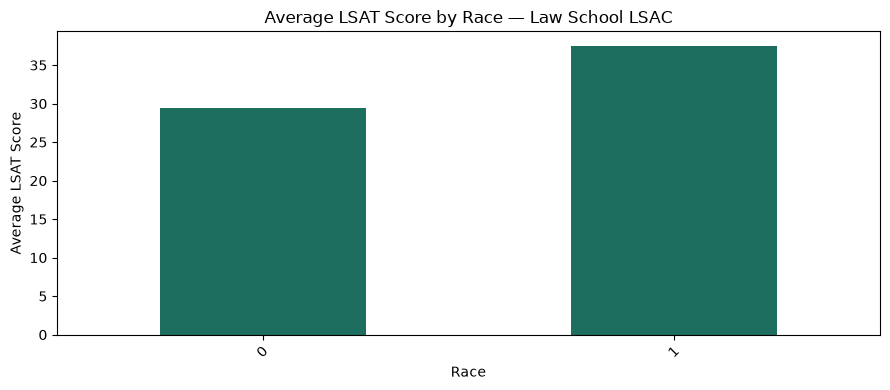


=== EDA SUMMARY — LAW SCHOOL LSAC DATASET ===
Total records:        18,692
Missing values:       0
Overall pass rate:    90.2%
Male pass rate:       91.1%
Female pass rate:     89.0%
Gender gap:           2.1 percentage points
Highest race pass:    1 92.1%
Lowest race pass:     0 61.8%
Racial gap:           30.3 percentage points

EDA COMPLETE — Law School dataset ready for preprocessing


In [5]:
# ── CELL 5: LSAT Score by Race ────────────────────
lsat_by_race = df_law.groupby('racetxt')['lsat'].mean().round(2).sort_values()
print("=== AVERAGE LSAT SCORE BY RACE ===")
print(lsat_by_race)

plt.figure(figsize=(9,4))
lsat_by_race.plot(kind='bar', color='#1D6E5E')
plt.title('Average LSAT Score by Race — Law School LSAC')
plt.ylabel('Average LSAT Score')
plt.xlabel('Race')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(r'C:\Users\niyat\Desktop\pr\ML-Bias-Fairness\results\lawschool_lsat_by_race.png', dpi=150)
plt.show()

# EDA Summary
print("\n=== EDA SUMMARY — LAW SCHOOL LSAC DATASET ===")
print(f"Total records:        {len(df_law):,}")
print(f"Missing values:       {df_law.isnull().sum().sum()}")
print(f"Overall pass rate:    {df_law['pass_bar'].mean()*100:.1f}%")
print(f"Male pass rate:       {gender_pass.get('Male',0):.1f}%")
print(f"Female pass rate:     {gender_pass.get('Female',0):.1f}%")
print(f"Gender gap:           {abs(gender_pass.get('Male',0)-gender_pass.get('Female',0)):.1f} percentage points")
print(f"Highest race pass:    {race_pass.index[-1]} {race_pass.iloc[-1]:.1f}%")
print(f"Lowest race pass:     {race_pass.index[0]} {race_pass.iloc[0]:.1f}%")
print(f"Racial gap:           {race_pass.max()-race_pass.min():.1f} percentage points")
print("\nEDA COMPLETE — Law School dataset ready for preprocessing")